In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
IMAGE_DIR = r"C:\Users\areej\Downloads\brisc2025\segmentation_task\train\images"
MASK_DIR = r"C:\Users\areej\Downloads\brisc2025\segmentation_task\train\masks"

In [5]:
import os
import numpy as np
from PIL import Image

IMAGE_DIR = r"C:\Users\areej\Downloads\brisc2025\brisc2025\segmentation_task\train\images"
MASK_DIR = r"C:\Users\areej\Downloads\brisc2025\brisc2025\segmentation_task\train\masks"

image_path = os.path.join(
    IMAGE_DIR,
    "brisc2025_train_00001_gl_ax_t1.jpg"
)

mask_path = os.path.join(
    MASK_DIR,
    "brisc2025_train_00001_gl_ax_t1.png"
)

print("Image exists:", os.path.exists(image_path))
print("Mask exists:", os.path.exists(mask_path))

Image exists: True
Mask exists: True


In [6]:
image = Image.open(image_path).convert("L")
mask = Image.open(mask_path).convert("L")

image_array = np.array(image)
mask_array = np.array(mask)

print("Image shape:", image_array.shape)
print("Mask shape:", mask_array.shape)
print("Image data type:", image_array.dtype)
print("Mask data type:", mask_array.dtype)

Image shape: (512, 512)
Mask shape: (512, 512)
Image data type: uint8
Mask data type: uint8


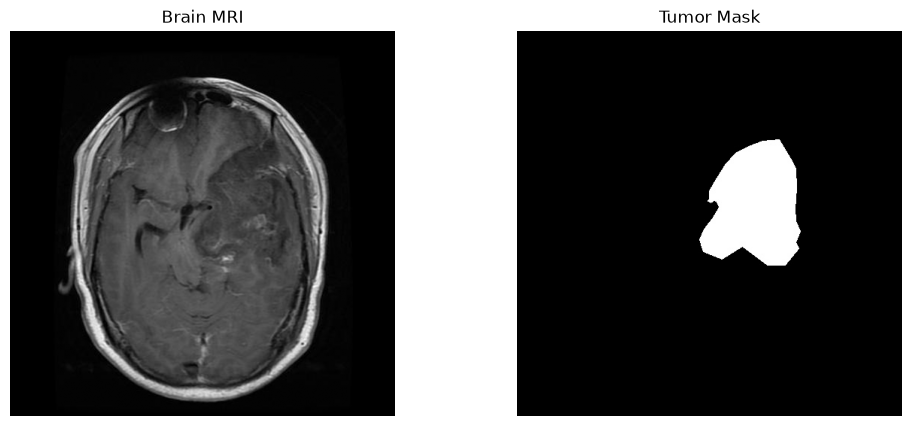

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_array, cmap="gray")
plt.title("Brain MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_array, cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

plt.show()

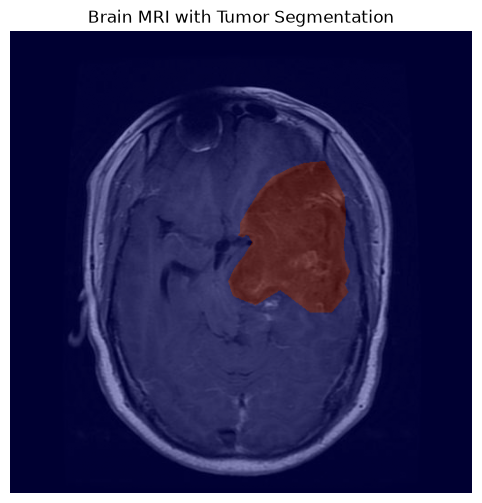

In [8]:
plt.figure(figsize=(6, 6))

plt.imshow(image_array, cmap="gray")
plt.imshow(mask_array, cmap="jet", alpha=0.4)

plt.title("Brain MRI with Tumor Segmentation")
plt.axis("off")

plt.show()

In [9]:
image_files = [
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

mask_files = [
    f for f in os.listdir(MASK_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

print("Number of images:", len(image_files))
print("Number of masks:", len(mask_files))

Number of images: 3933
Number of masks: 3933


In [10]:
image_basenames = {
    os.path.splitext(f)[0]
    for f in image_files
}

mask_basenames = {
    os.path.splitext(f)[0]
    for f in mask_files
}

missing_masks = image_basenames - mask_basenames
extra_masks = mask_basenames - image_basenames

print("Images without masks:", len(missing_masks))
print("Masks without images:", len(extra_masks))

Images without masks: 0
Masks without images: 0


In [11]:
unique_values = np.unique(mask_array)

print("Unique mask values:", unique_values)
print("Number of unique values:", len(unique_values))

Unique mask values: [  0   1   2   3   4   5   6   7 248 249 250 251 252 253 254 255]
Number of unique values: 16


In [12]:
from collections import Counter

values, counts = np.unique(mask_array, return_counts=True)

for value, count in zip(values, counts):
    print(f"Value {value:3d}: {count:8d} pixels")

Value   0:   244991 pixels
Value   1:      398 pixels
Value   2:      227 pixels
Value   3:      117 pixels
Value   4:       39 pixels
Value   5:       20 pixels
Value   6:        6 pixels
Value   7:        1 pixels
Value 248:        2 pixels
Value 249:        2 pixels
Value 250:       26 pixels
Value 251:       44 pixels
Value 252:      111 pixels
Value 253:      220 pixels
Value 254:      413 pixels
Value 255:    15527 pixels


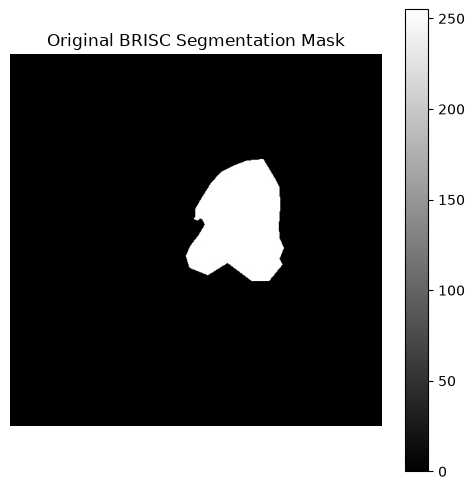

In [13]:
plt.figure(figsize=(6, 6))
plt.imshow(mask_array, cmap="gray", vmin=0, vmax=255)
plt.colorbar()
plt.title("Original BRISC Segmentation Mask")
plt.axis("off")
plt.show()

In [14]:
binary_mask = (mask_array > 0).astype(np.uint8)

print("Original unique values:", np.unique(mask_array))
print("Binary mask values:", np.unique(binary_mask))

Original unique values: [  0   1   2   3   4   5   6   7 248 249 250 251 252 253 254 255]
Binary mask values: [0 1]


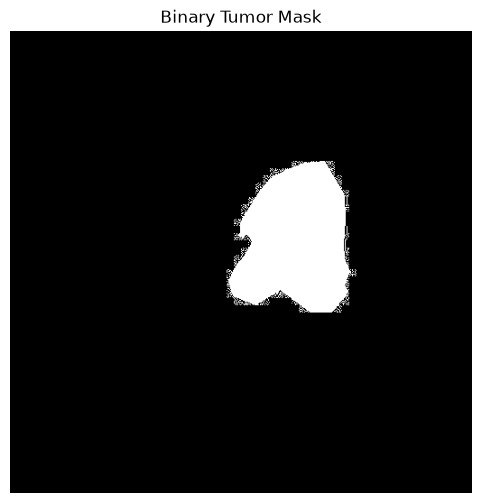

In [15]:
plt.figure(figsize=(6, 6))

plt.imshow(binary_mask, cmap="gray")
plt.title("Binary Tumor Mask")
plt.axis("off")

plt.show()

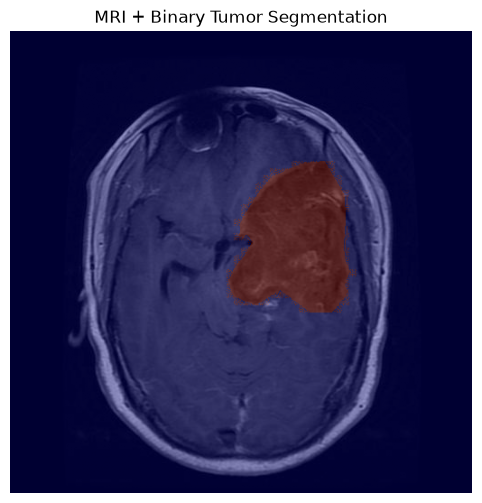

In [16]:
plt.figure(figsize=(6, 6))

plt.imshow(image_array, cmap="gray")
plt.imshow(binary_mask, cmap="jet", alpha=0.4)

plt.title("MRI + Binary Tumor Segmentation")
plt.axis("off")

plt.show()

In [17]:
IMG_SIZE = 256

image_resized = Image.fromarray(image_array).resize(
    (IMG_SIZE, IMG_SIZE),
    Image.Resampling.BILINEAR
)

mask_resized = Image.fromarray(binary_mask).resize(
    (IMG_SIZE, IMG_SIZE),
    Image.Resampling.NEAREST
)

image_resized = np.array(image_resized)
mask_resized = np.array(mask_resized)

print("Image shape:", image_resized.shape)
print("Mask shape:", mask_resized.shape)
print("Mask values:", np.unique(mask_resized))

Image shape: (256, 256)
Mask shape: (256, 256)
Mask values: [0 1]


In [18]:
image_normalized = image_resized.astype(np.float32) / 255.0

print("Minimum:", image_normalized.min())
print("Maximum:", image_normalized.max())

Minimum: 0.0
Maximum: 0.92156863


In [19]:
import random

random.seed(42)

image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

mask_files = sorted([
    f for f in os.listdir(MASK_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

print("Total images:", len(image_files))
print("Total masks:", len(mask_files))

Total images: 3933
Total masks: 3933


In [20]:
image_dict = {
    os.path.splitext(f)[0]: f
    for f in image_files
}

mask_dict = {
    os.path.splitext(f)[0]: f
    for f in mask_files
}

common_names = sorted(set(image_dict) & set(mask_dict))

print("Matched image-mask pairs:", len(common_names))

Matched image-mask pairs: 3933


In [21]:
random.shuffle(common_names)

selected_names = common_names[:1000]

train_names = selected_names[:800]
val_names = selected_names[800:1000]

print("Training images:", len(train_names))
print("Validation images:", len(val_names))

Training images: 800
Validation images: 200


In [22]:
from tensorflow.keras.utils import Sequence

class BrainMRIGenerator(Sequence):
    def __init__(self, names, image_dir, mask_dir, batch_size=8, img_size=256, shuffle=True):
        self.names = names
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.names))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.names) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[
            index * self.batch_size:(index + 1) * self.batch_size
        ]

        batch_names = [self.names[i] for i in batch_indices]

        images = []
        masks = []

        for name in batch_names:
            image_path = os.path.join(
                self.image_dir,
                image_dict[name]
            )

            mask_path = os.path.join(
                self.mask_dir,
                mask_dict[name]
            )

            image = Image.open(image_path).convert("L")
            mask = Image.open(mask_path).convert("L")

            image = image.resize(
                (self.img_size, self.img_size),
                Image.Resampling.BILINEAR
            )

            mask = mask.resize(
                (self.img_size, self.img_size),
                Image.Resampling.NEAREST
            )

            image = np.array(image, dtype=np.float32) / 255.0

            mask = np.array(mask, dtype=np.uint8)
            mask = (mask > 0).astype(np.float32)

            images.append(image[..., np.newaxis])
            masks.append(mask[..., np.newaxis])

        return np.array(images), np.array(masks)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [23]:
train_generator = BrainMRIGenerator(
    train_names,
    IMAGE_DIR,
    MASK_DIR,
    batch_size=8,
    img_size=256,
    shuffle=True
)

val_generator = BrainMRIGenerator(
    val_names,
    IMAGE_DIR,
    MASK_DIR,
    batch_size=8,
    img_size=256,
    shuffle=False
)

print("Training batches:", len(train_generator))
print("Validation batches:", len(val_generator))

Training batches: 100
Validation batches: 25


In [24]:
X_batch, y_batch = train_generator[0]

print("Image batch shape:", X_batch.shape)
print("Mask batch shape:", y_batch.shape)
print("Image range:", X_batch.min(), "to", X_batch.max())
print("Mask values:", np.unique(y_batch))

Image batch shape: (8, 256, 256, 1)
Mask batch shape: (8, 256, 256, 1)
Image range: 0.0 to 1.0
Mask values: [0. 1.]


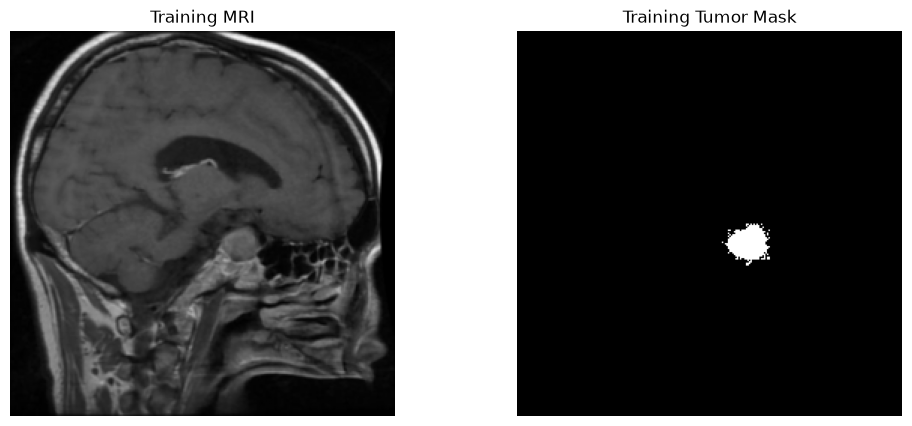

In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(X_batch[0].squeeze(), cmap="gray")
plt.title("Training MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(y_batch[0].squeeze(), cmap="gray")
plt.title("Training Tumor Mask")
plt.axis("off")

plt.show()

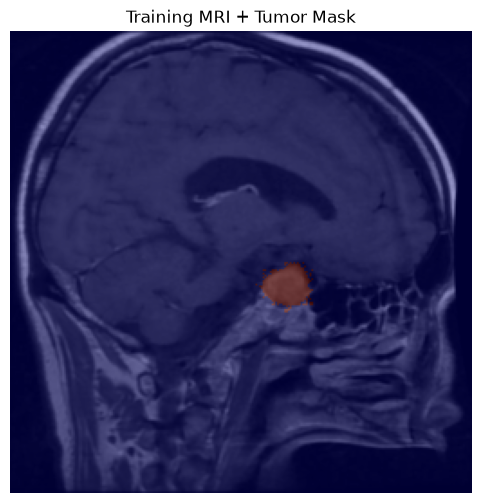

In [26]:
plt.figure(figsize=(6, 6))

plt.imshow(X_batch[0].squeeze(), cmap="gray")
plt.imshow(y_batch[0].squeeze(), cmap="jet", alpha=0.4)

plt.title("Training MRI + Tumor Mask")
plt.axis("off")

plt.show()

In [27]:
import tensorflow as tf
from tensorflow.keras import layers, models


def build_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    # Encoder - Block 1
    c1 = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    c1 = layers.Conv2D(32, 3, activation="relu", padding="same")(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    # Encoder - Block 2
    c2 = layers.Conv2D(64, 3, activation="relu", padding="same")(p1)
    c2 = layers.Conv2D(64, 3, activation="relu", padding="same")(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Encoder - Block 3
    c3 = layers.Conv2D(128, 3, activation="relu", padding="same")(p2)
    c3 = layers.Conv2D(128, 3, activation="relu", padding="same")(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # Bottleneck
    c4 = layers.Conv2D(256, 3, activation="relu", padding="same")(p3)
    c4 = layers.Conv2D(256, 3, activation="relu", padding="same")(c4)

    # Decoder - Block 1
    u5 = layers.UpSampling2D((2, 2))(c4)
    u5 = layers.Concatenate()([u5, c3])
    c5 = layers.Conv2D(128, 3, activation="relu", padding="same")(u5)
    c5 = layers.Conv2D(128, 3, activation="relu", padding="same")(c5)

    # Decoder - Block 2
    u6 = layers.UpSampling2D((2, 2))(c5)
    u6 = layers.Concatenate()([u6, c2])
    c6 = layers.Conv2D(64, 3, activation="relu", padding="same")(u6)
    c6 = layers.Conv2D(64, 3, activation="relu", padding="same")(c6)

    # Decoder - Block 3
    u7 = layers.UpSampling2D((2, 2))(c6)
    u7 = layers.Concatenate()([u7, c1])
    c7 = layers.Conv2D(32, 3, activation="relu", padding="same")(u7)
    c7 = layers.Conv2D(32, 3, activation="relu", padding="same")(c7)

    # Output
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c7)

    model = models.Model(inputs, outputs)

    return model


model = build_unet()

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 256, 256, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 256, 256, 32)      │             320 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 256, 256, 32)      │           9,248 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 128, 128, 32)      │               0 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 128, 128, 64)      │          18,496 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 128, 128, 64)      │          36,928 │ conv2d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 64, 64, 64)        │               0 │ conv2d_3[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 64, 64, 128)       │          73,856 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 64, 64, 128)       │         147,584 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 32, 32, 128)       │               0 │ conv2d_5[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 32, 32, 256)       │         295,168 │ max_pooling2d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 32, 32, 256)       │         590,080 │ conv2d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d (UpSampling2D)  │ (None, 64, 64, 256)       │               0 │ conv2d_7[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 64, 64, 384)       │               0 │ up_sampling2d[0][0],       │
│                               │                           │                 │ conv2d_5[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_8 (Conv2D)             │ (None, 64, 64, 128)       │         442,496 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_9 (Conv2D)             │ (None, 64, 64, 128)       │         147,58

 Total params: 1,946,305 (7.42 MB)

 Trainable params: 1,946,305 (7.42 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true * y_pred)

    dice = (
        (2.0 * intersection + smooth)
        /
        (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)
    )

    return dice

In [29]:
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

In [30]:
def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)

    return tf.reduce_mean(bce) + dice_loss(y_true, y_pred)

In [31]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[dice_coefficient]
)

print("U-Net compiled successfully!")

U-Net compiled successfully!


In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 4

print("New image size:", IMG_SIZE)
print("New batch size:", BATCH_SIZE)

In [1]:
print("Hello Areej")

Hello Areej


In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
IMAGE_DIR = r"C:\Users\areej\Downloads\brisc2025\brisc2025\segmentation_task\train\images"
MASK_DIR = r"C:\Users\areej\Downloads\brisc2025\brisc2025\segmentation_task\train\masks"

print("Images folder exists:", os.path.exists(IMAGE_DIR))
print("Masks folder exists:", os.path.exists(MASK_DIR))

Images folder exists: True
Masks folder exists: True


In [5]:
image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

mask_files = sorted([
    f for f in os.listdir(MASK_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

image_dict = {
    os.path.splitext(f)[0]: f
    for f in image_files
}

mask_dict = {
    os.path.splitext(f)[0]: f
    for f in mask_files
}

common_names = sorted(set(image_dict) & set(mask_dict))

print("Images:", len(image_files))
print("Masks:", len(mask_files))
print("Matched pairs:", len(common_names))

Images: 3933
Masks: 3933
Matched pairs: 3933


In [6]:
random.seed(42)
random.shuffle(common_names)

train_names = common_names[:100]
val_names = common_names[100:125]

print("Training images:", len(train_names))
print("Validation images:", len(val_names))

Training images: 100
Validation images: 25


In [7]:
from tensorflow.keras.utils import Sequence

class BrainMRIGenerator(Sequence):

    def __init__(
        self,
        names,
        image_dir,
        mask_dir,
        batch_size=8,
        img_size=128,
        shuffle=True,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.names = names
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle

        self.indices = np.arange(len(self.names))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.names) / self.batch_size))

    def __getitem__(self, index):

        batch_indices = self.indices[
            index * self.batch_size:
            (index + 1) * self.batch_size
        ]

        images = []
        masks = []

        for i in batch_indices:

            name = self.names[i]

            image_path = os.path.join(
                IMAGE_DIR,
                image_dict[name]
            )

            mask_path = os.path.join(
                MASK_DIR,
                mask_dict[name]
            )

            # Load image
            image = Image.open(image_path).convert("L")

            # Load mask
            mask = Image.open(mask_path).convert("L")

            # Resize
            image = image.resize(
                (self.img_size, self.img_size),
                Image.Resampling.BILINEAR
            )

            mask = mask.resize(
                (self.img_size, self.img_size),
                Image.Resampling.NEAREST
            )

            # Convert to arrays
            image = np.array(image, dtype=np.float32) / 255.0
            mask = np.array(mask, dtype=np.uint8)

            # Convert mask to binary
            mask = (mask > 0).astype(np.float32)

            # Add channel dimension
            images.append(image[..., np.newaxis])
            masks.append(mask[..., np.newaxis])

        return np.array(images), np.array(masks)

    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.indices)

In [8]:
train_generator = BrainMRIGenerator(
    train_names,
    IMAGE_DIR,
    MASK_DIR,
    batch_size=8,
    img_size=128
)

val_generator = BrainMRIGenerator(
    val_names,
    IMAGE_DIR,
    MASK_DIR,
    batch_size=8,
    img_size=128,
    shuffle=False
)

print("Training batches:", len(train_generator))
print("Validation batches:", len(val_generator))

Training batches: 13
Validation batches: 4


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_small_unet(input_shape=(128, 128, 1)):

    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation="relu", padding="same")(inputs)
    c1 = layers.Conv2D(16, 3, activation="relu", padding="same")(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(32, 3, activation="relu", padding="same")(p1)
    c2 = layers.Conv2D(32, 3, activation="relu", padding="same")(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(64, 3, activation="relu", padding="same")(p2)
    c3 = layers.Conv2D(64, 3, activation="relu", padding="same")(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # Bottleneck
    c4 = layers.Conv2D(128, 3, activation="relu", padding="same")(p3)
    c4 = layers.Conv2D(128, 3, activation="relu", padding="same")(c4)

    # Decoder
    u5 = layers.UpSampling2D((2, 2))(c4)
    u5 = layers.Concatenate()([u5, c3])
    c5 = layers.Conv2D(64, 3, activation="relu", padding="same")(u5)
    c5 = layers.Conv2D(64, 3, activation="relu", padding="same")(c5)

    u6 = layers.UpSampling2D((2, 2))(c5)
    u6 = layers.Concatenate()([u6, c2])
    c6 = layers.Conv2D(32, 3, activation="relu", padding="same")(u6)
    c6 = layers.Conv2D(32, 3, activation="relu", padding="same")(c6)

    u7 = layers.UpSampling2D((2, 2))(c6)
    u7 = layers.Concatenate()([u7, c1])
    c7 = layers.Conv2D(16, 3, activation="relu", padding="same")(u7)
    c7 = layers.Conv2D(16, 3, activation="relu", padding="same")(c7)

    # Output
    outputs = layers.Conv2D(
        1, 1, activation="sigmoid"
    )(c7)

    return models.Model(inputs, outputs)


model = build_small_unet()

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 128, 128, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 128, 128, 16)      │             160 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 128, 128, 16)      │           2,320 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 64, 64, 16)        │               0 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 64, 64, 32)        │           4,640 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 64, 64, 32)        │           9,248 │ conv2d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 32, 32, 32)        │               0 │ conv2d_3[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 32, 32, 64)        │          18,496 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 32, 32, 64)        │          36,928 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 16, 16, 64)        │               0 │ conv2d_5[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 16, 16, 128)       │          73,856 │ max_pooling2d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 16, 16, 128)       │         147,584 │ conv2d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d (UpSampling2D)  │ (None, 32, 32, 128)       │               0 │ conv2d_7[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 32, 32, 192)       │               0 │ up_sampling2d[0][0],       │
│                               │                           │                 │ conv2d_5[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_8 (Conv2D)             │ (None, 32, 32, 64)        │         110,656 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_9 (Conv2D)             │ (None, 32, 32, 64)        │          36,92

 Total params: 487,009 (1.86 MB)

 Trainable params: 487,009 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true * y_pred)

    dice = (
        (2.0 * intersection + smooth)
        /
        (
            tf.reduce_sum(y_true)
            + tf.reduce_sum(y_pred)
            + smooth
        )
    )

    return dice


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)


def combined_loss(y_true, y_pred):

    bce = tf.keras.losses.binary_crossentropy(
        y_true,
        y_pred
    )

    return tf.reduce_mean(bce) + dice_loss(
        y_true,
        y_pred
    )


print("Dice loss functions ready!")

Dice loss functions ready!


In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=combined_loss,
    metrics=[dice_coefficient]
)

print("Model compiled successfully!")

Model compiled successfully!


In [12]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 88s 5s/step - dice_coefficient: 0.0364 - loss: 1.6487 - val_dice_coefficient: 0.0232 - val_loss: 1.6495


In [13]:
history_more = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=4
)

Epoch 1/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 53s 4s/step - dice_coefficient: 0.0354 - loss: 1.6115 - val_dice_coefficient: 0.0213 - val_loss: 1.5264
Epoch 2/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 80s 4s/step - dice_coefficient: 0.0167 - loss: 1.3258 - val_dice_coefficient: 7.2807e-05 - val_loss: 1.1614
Epoch 3/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step - dice_coefficient: 8.3542e-04 - loss: 1.2123 - val_dice_coefficient: 0.0035 - val_loss: 1.1402
Epoch 4/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - dice_coefficient: 0.0061 - loss: 1.1688 - val_dice_coefficient: 0.0023 - val_loss: 1.1146


In [14]:
print("Training complete.")
print("Best validation Dice from these epochs:",
      max(history.history["val_dice_coefficient"] +
          history_more.history["val_dice_coefficient"]))

Training complete.
Best validation Dice from these epochs: 0.023165997117757797


In [15]:
# Get one validation batch
X_val, y_val = val_generator[0]

# Predict tumor mask
predictions = model.predict(X_val)

print("Input shape:", X_val.shape)
print("Prediction shape:", predictions.shape)
print("Prediction range:",
      predictions.min(), "to", predictions.max())

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Input shape: (8, 128, 128, 1)
Prediction shape: (8, 128, 128, 1)
Prediction range: 0.0013890219 to 0.49744284


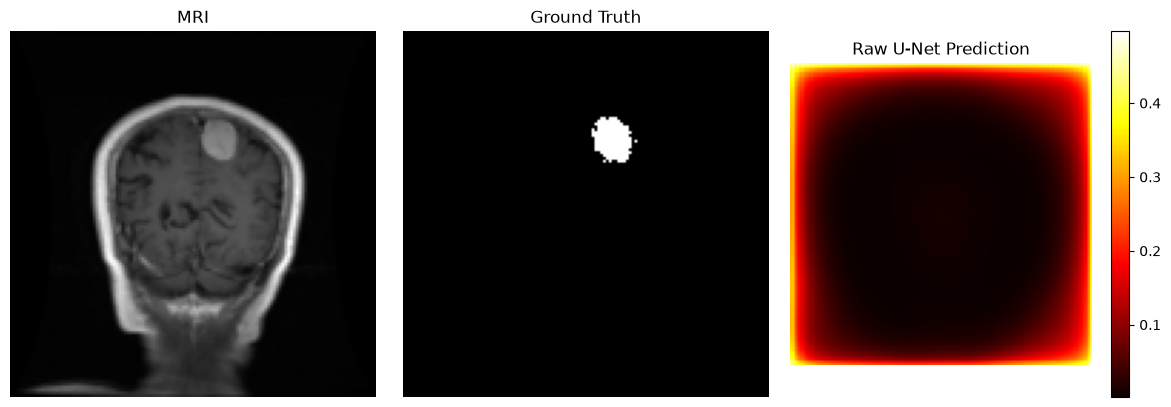

In [16]:
sample = 0

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(X_val[sample].squeeze(), cmap="gray")
plt.title("MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(y_val[sample].squeeze(), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(predictions[sample].squeeze(), cmap="hot")
plt.colorbar()
plt.title("Raw U-Net Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
print("Prediction mean:", predictions.mean())
print("Prediction max:", predictions.max())
print("Ground-truth tumor pixels:", y_val.sum())

Prediction mean: 0.048080053
Prediction max: 0.49744284
Ground-truth tumor pixels: 1716.0


In [18]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true * y_pred)

    return (
        (2.0 * intersection + smooth)
        /
        (
            tf.reduce_sum(y_true)
            + tf.reduce_sum(y_pred)
            + smooth
        )
    )


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)


def combined_loss(y_true, y_pred):

    bce = tf.keras.losses.binary_crossentropy(
        y_true,
        y_pred
    )

    return 0.3 * tf.reduce_mean(bce) + dice_loss(
        y_true,
        y_pred
    )


print("New loss function ready!")

New loss function ready!


In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=combined_loss,
    metrics=[dice_coefficient]
)

print("Model recompiled!")

Model recompiled!


In [20]:
history_new = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=2
)

Epoch 1/2
13/13 ━━━━━━━━━━━━━━━━━━━━ 64s 4s/step - dice_coefficient: 0.0112 - loss: 1.0377 - val_dice_coefficient: 0.0067 - val_loss: 1.0243
Epoch 2/2
13/13 ━━━━━━━━━━━━━━━━━━━━ 76s 4s/step - dice_coefficient: 0.0191 - loss: 1.0217 - val_dice_coefficient: 0.0165 - val_loss: 1.0123


In [21]:
class BrainMRIGenerator(Sequence):

    def __init__(
        self,
        names,
        image_dir,
        mask_dir,
        batch_size=8,
        img_size=128,
        shuffle=True,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.names = names
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle

        self.indices = np.arange(len(self.names))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.names) / self.batch_size))

    def __getitem__(self, index):

        batch_indices = self.indices[
            index * self.batch_size:
            (index + 1) * self.batch_size
        ]

        images = []
        masks = []

        for i in batch_indices:

            name = self.names[i]

            image_path = os.path.join(
                self.image_dir,
                image_dict[name]
            )

            mask_path = os.path.join(
                self.mask_dir,
                mask_dict[name]
            )

            image = Image.open(image_path).convert("L")
            mask = Image.open(mask_path).convert("L")

            image = image.resize(
                (self.img_size, self.img_size),
                Image.Resampling.BILINEAR
            )

            mask = mask.resize(
                (self.img_size, self.img_size),
                Image.Resampling.NEAREST
            )

            # Normalize MRI
            image = np.array(
                image,
                dtype=np.float32
            ) / 255.0

            # Normalize mask first
            mask = np.array(
                mask,
                dtype=np.float32
            ) / 255.0

            # Correct binary mask
            mask = (mask > 0.5).astype(np.float32)

            images.append(image[..., np.newaxis])
            masks.append(mask[..., np.newaxis])

        return np.array(images), np.array(masks)

    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.indices)

In [22]:
X_check, y_check = train_generator[0]

print("Mask values:", np.unique(y_check))
print("Tumor pixels:", y_check.sum())

Mask values: [0. 1.]
Tumor pixels: 3424.0


In [23]:
model = build_small_unet(input_shape=(128, 128, 1))

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=combined_loss,
    metrics=[dice_coefficient]
)

print("Fresh U-Net created and compiled!")

Fresh U-Net created and compiled!


In [24]:
history_final = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3
)

Epoch 1/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 61s 4s/step - dice_coefficient: 0.0367 - loss: 1.1695 - val_dice_coefficient: 0.0232 - val_loss: 1.1786
Epoch 2/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step - dice_coefficient: 0.0360 - loss: 1.1566 - val_dice_coefficient: 0.0208 - val_loss: 1.1364
Epoch 3/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - dice_coefficient: 0.0152 - loss: 1.0831 - val_dice_coefficient: 2.2624e-04 - val_loss: 1.0466


In [25]:
X_val, y_val = val_generator[0]

predictions = model.predict(X_val)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


FileNotFoundError: [Errno 2] No such file or directory: 'results/segmentation_result.png'

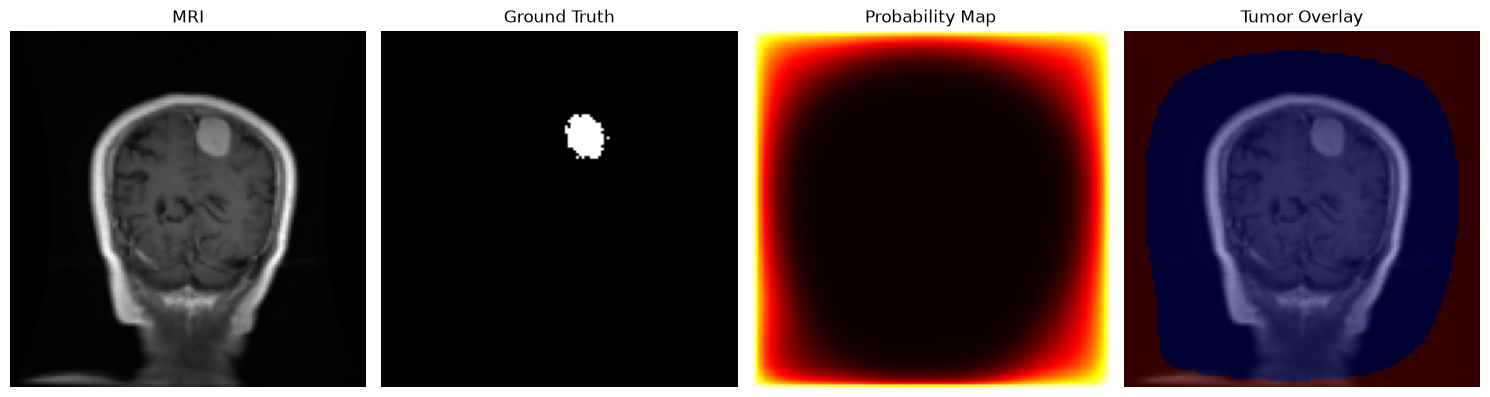

In [26]:
sample = 0

pred_mask = (predictions[sample] > 0.1).astype(np.float32)

plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(X_val[sample].squeeze(), cmap='gray')
plt.title("MRI")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(y_val[sample].squeeze(), cmap='gray')
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(predictions[sample].squeeze(), cmap='hot')
plt.title("Probability Map")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(X_val[sample].squeeze(), cmap='gray')
plt.imshow(pred_mask.squeeze(), alpha=0.4, cmap='jet')
plt.title("Tumor Overlay")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "results/segmentation_result.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
import os

print("Current folder:")
print(os.getcwd())

Current folder:
C:\Users\areej\Documents\brain-mri-tumor-segmentation\notebooks


In [28]:
os.makedirs("results", exist_ok=True)

print("Results folder is ready!")

Results folder is ready!


In [29]:
plt.savefig(
    "results/segmentation_result.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [30]:
plt.show()

In [31]:
import os

print("Current folder:", os.getcwd())
print("Results folder exists:", os.path.exists("results"))
print("Image saved:", os.path.exists("results/segmentation_result.png"))

Current folder: C:\Users\areej\Documents\brain-mri-tumor-segmentation\notebooks
Results folder exists: True
Image saved: True


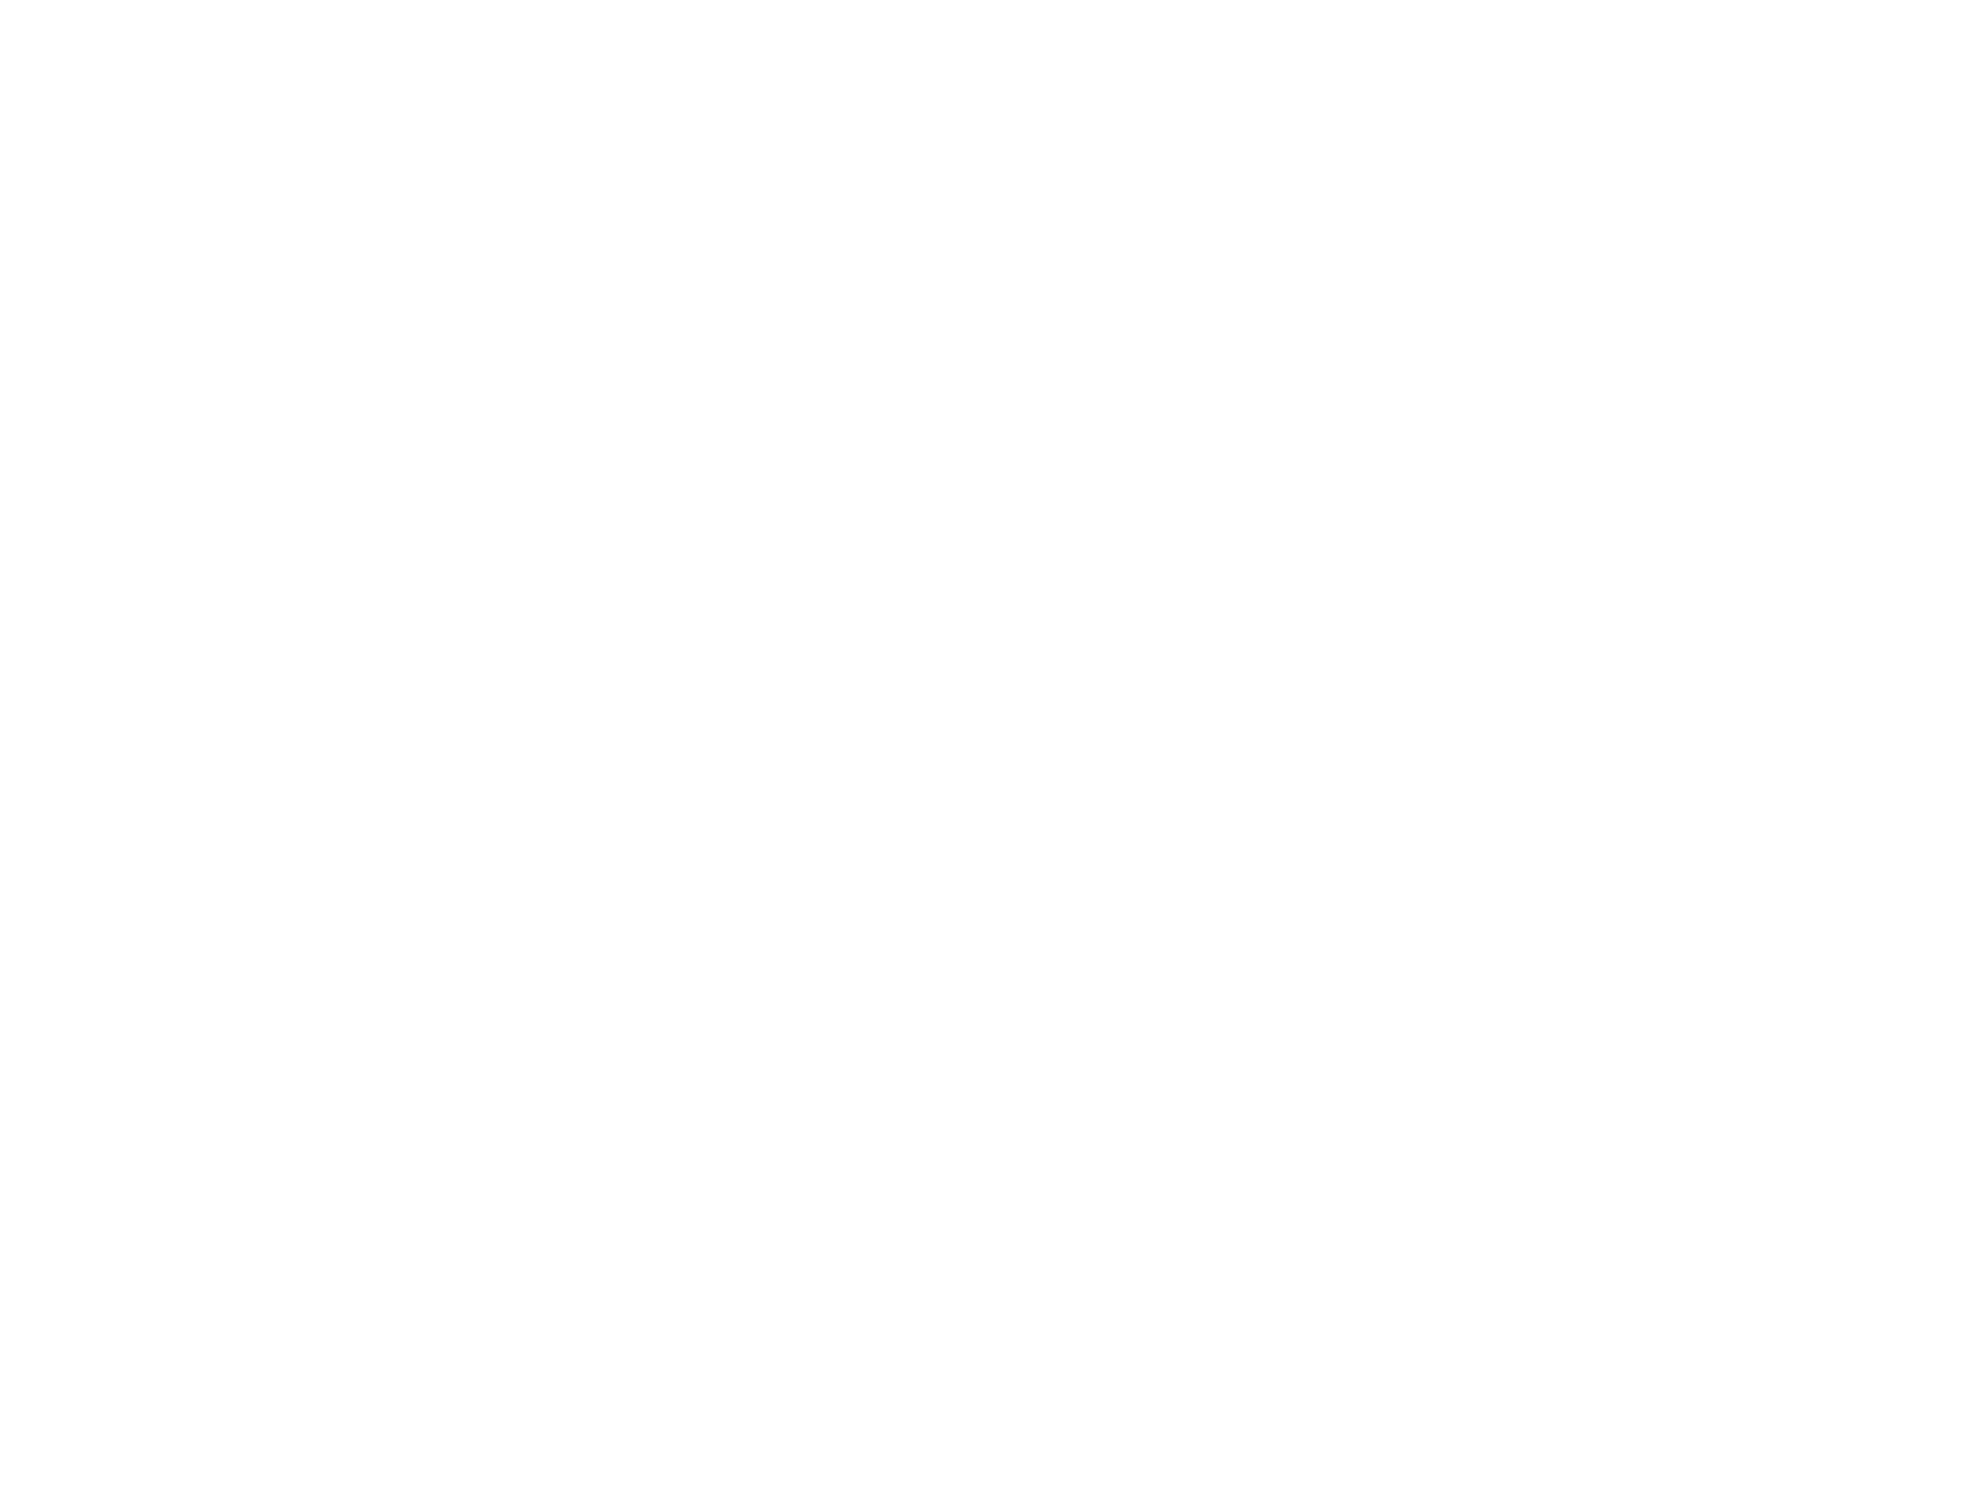

In [33]:
from IPython.display import Image, display

display(Image(filename="results/segmentation_result.png"))

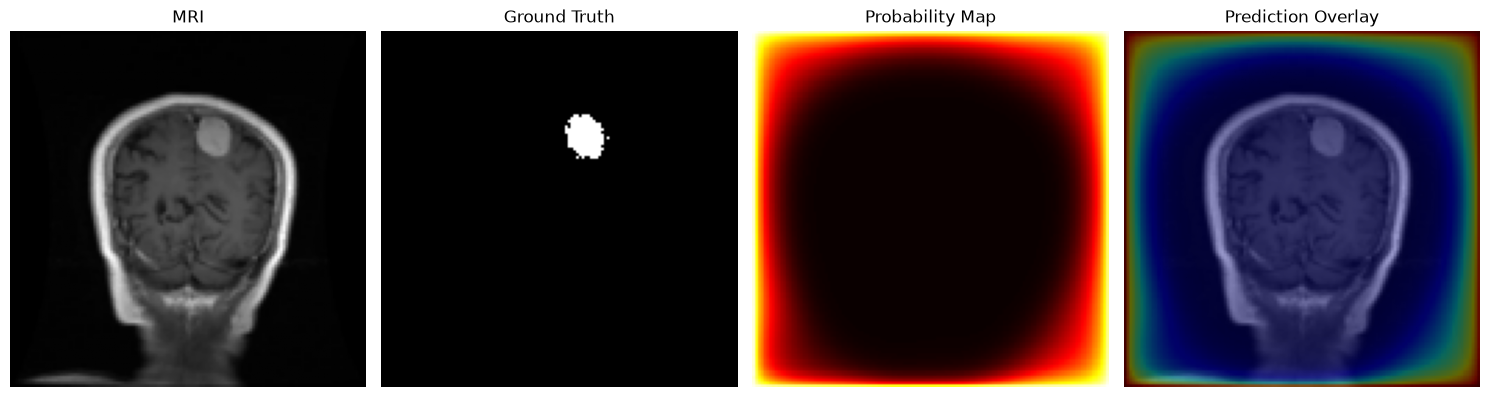

In [34]:
sample = 0

plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(X_val[sample].squeeze(), cmap="gray")
plt.title("MRI")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(y_val[sample].squeeze(), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(predictions[sample].squeeze(), cmap="hot")
plt.title("Probability Map")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(X_val[sample].squeeze(), cmap="gray")
plt.imshow(
    predictions[sample].squeeze(),
    cmap="jet",
    alpha=0.4
)
plt.title("Prediction Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

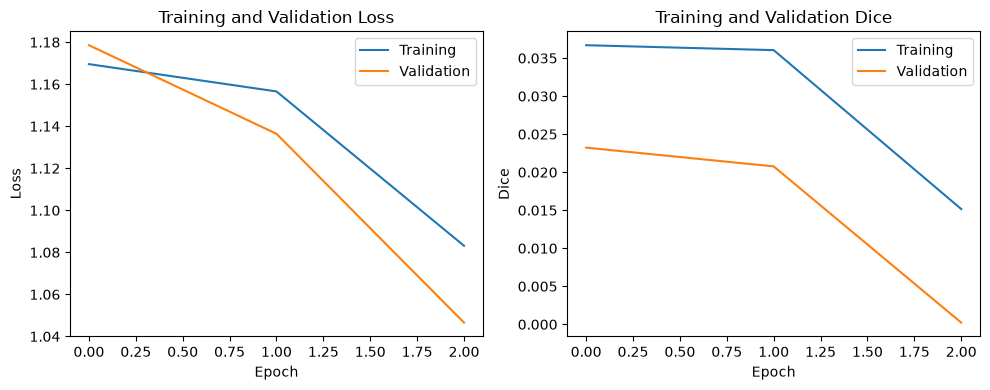

In [35]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_final.history["loss"])
plt.plot(history_final.history["val_loss"])
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training", "Validation"])

plt.subplot(1, 2, 2)
plt.plot(history_final.history["dice_coefficient"])
plt.plot(history_final.history["val_dice_coefficient"])
plt.title("Training and Validation Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend(["Training", "Validation"])

plt.tight_layout()

plt.savefig(
    "results/training_curves.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [36]:
model.save("results/brain_tumor_unet.keras")

print("Model saved successfully!")

Model saved successfully!


In [37]:
from PIL import Image
import numpy as np
import os

# Use the same validation sample we visualized
sample = 0

# Convert model probability to binary mask
pred_mask = (predictions[sample].squeeze() > 0.1).astype(np.uint8) * 255

# Save predicted mask
os.makedirs("results", exist_ok=True)

predicted_mask_path = "results/predicted_mask.png"
Image.fromarray(pred_mask).save(predicted_mask_path)

print("Predicted mask saved:", predicted_mask_path)

Predicted mask saved: results/predicted_mask.png


In [38]:
# Save the MRI image corresponding to the prediction
mri_image = (X_val[sample].squeeze() * 255).astype(np.uint8)

mri_path = "results/mri_sample.png"
Image.fromarray(mri_image).save(mri_path)

print("MRI image saved:", mri_path)

MRI image saved: results/mri_sample.png


In [39]:
import os

print("Notebook is currently working in:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

Notebook is currently working in:
C:\Users\areej\Documents\brain-mri-tumor-segmentation\notebooks

Files in current folder:
['.ipynb_checkpoints', 'brain_tumor_segmentation.ipynb', 'results']


In [40]:
from PIL import Image
import numpy as np
import os

sample = 0

pred_mask = (predictions[sample].squeeze() > 0.1).astype(np.uint8) * 255

os.makedirs("results", exist_ok=True)

predicted_mask_path = "results/predicted_mask.png"
Image.fromarray(pred_mask).save(predicted_mask_path)

print("Predicted mask saved:", predicted_mask_path)

Predicted mask saved: results/predicted_mask.png


In [41]:
mri_image = (X_val[sample].squeeze() * 255).astype(np.uint8)

mri_path = "results/mri_sample.png"
Image.fromarray(mri_image).save(mri_path)

print("MRI image saved:", mri_path)

MRI image saved: results/mri_sample.png


In [42]:
# Generate fresh predictions from the final trained model
predictions_final = model.predict(X_val)

sample = 0

# Standard binary threshold
pred_mask = (
    predictions_final[sample].squeeze() > 0.5
).astype(np.uint8) * 255

Image.fromarray(pred_mask).save(
    "results/predicted_mask.png"
)

print("Prediction saved.")
print("Prediction range:",
      predictions_final[sample].min(),
      predictions_final[sample].max())
print("Tumor pixels at threshold 0.5:",
      np.sum(pred_mask > 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Prediction saved.
Prediction range: 0.00018830589 0.5001875
Tumor pixels at threshold 0.5: 1


In [43]:
def tversky_index(y_true, y_pred, alpha=0.3, beta=0.7, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    true_positive = tf.reduce_sum(y_true * y_pred)
    false_positive = tf.reduce_sum((1 - y_true) * y_pred)
    false_negative = tf.reduce_sum(y_true * (1 - y_pred))

    return (
        (true_positive + smooth) /
        (true_positive + alpha * false_positive + beta * false_negative + smooth)
    )


def tversky_loss(y_true, y_pred):
    return 1.0 - tversky_index(y_true, y_pred)


def combined_tversky_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return 0.5 * tf.reduce_mean(bce) + 0.5 * tversky_loss(y_true, y_pred)

In [44]:
model_ai = build_small_unet(input_shape=(128, 128, 1))

model_ai.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=combined_tversky_loss,
    metrics=[dice_coefficient]
)

model_ai.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 128, 128, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_30 (Conv2D)            │ (None, 128, 128, 16)      │             160 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_31 (Conv2D)            │ (None, 128, 128, 16)      │           2,320 │ conv2d_30[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_6               │ (None, 64, 64, 16)        │               0 │ conv2d_31[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_32 (Conv2D)            │ (None, 64, 64, 32)        │           4,640 │ max_pooling2d_6[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_33 (Conv2D)            │ (None, 64, 64, 32)        │           9,248 │ conv2d_32[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_7               │ (None, 32, 32, 32)        │               0 │ conv2d_33[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_34 (Conv2D)            │ (None, 32, 32, 64)        │          18,496 │ max_pooling2d_7[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_35 (Conv2D)            │ (None, 32, 32, 64)        │          36,928 │ conv2d_34[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_8               │ (None, 16, 16, 64)        │               0 │ conv2d_35[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_36 (Conv2D)            │ (None, 16, 16, 128)       │          73,856 │ max_pooling2d_8[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_37 (Conv2D)            │ (None, 16, 16, 128)       │         147,584 │ conv2d_36[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d_6               │ (None, 32, 32, 128)       │               0 │ conv2d_37[0][0]            │
│ (UpSampling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_6 (Concatenate)   │ (None, 32, 32, 192)       │               0 │ up_sampling2d_6[0][0],     │
│                               │                           │                 │ conv2d_35[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_38 (Conv2D)            │ (None, 32, 32, 64)        │         110,65

 Total params: 487,009 (1.86 MB)

 Trainable params: 487,009 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_dice_coefficient",
    mode="max",
    patience=3,
    restore_best_weights=True
)

history_ai = model_ai.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 402s 29s/step - dice_coefficient: 0.0196 - loss: 0.7106 - val_dice_coefficient: 0.0117 - val_loss: 0.5852
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 95s 7s/step - dice_coefficient: 0.0127 - loss: 0.5618 - val_dice_coefficient: 0.0152 - val_loss: 0.5286
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 132s 6s/step - dice_coefficient: 0.0664 - loss: 0.5089 - val_dice_coefficient: 0.0405 - val_loss: 0.5318
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 133s 6s/step - dice_coefficient: 0.0905 - loss: 0.5007 - val_dice_coefficient: 0.0431 - val_loss: 0.5425
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 84s 6s/step - dice_coefficient: 0.0968 - loss: 0.4962 - val_dice_coefficient: 0.0501 - val_loss: 0.5194
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 155s 7s/step - dice_coefficient: 0.1054 - loss: 0.4874 - val_dice_coefficient: 0.0518 - val_loss: 0.5196
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 82s 6s/step - dice_coefficient: 0.1096 - loss: 0.4846 - val_dice_coefficient: 0.0629 - val_loss: 0.5118
E

In [46]:
model_ai.save("results/brain_tumor_unet_tversky.keras")

print("Improved AI model saved successfully!")

Improved AI model saved successfully!


In [47]:
predictions_ai = model_ai.predict(X_val)

print("Prediction shape:", predictions_ai.shape)
print("Prediction range:",
      predictions_ai.min(),
      predictions_ai.max())

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
Prediction shape: (8, 128, 128, 1)
Prediction range: 9.088824e-24 0.49196205


In [48]:
# Predict on the complete validation set
all_val_predictions = model_ai.predict(val_generator)

# Collect the corresponding ground-truth masks
all_val_masks = []

for i in range(len(val_generator)):
    _, masks = val_generator[i]
    all_val_masks.append(masks)

all_val_masks = np.concatenate(all_val_masks, axis=0)

print("Predictions:", all_val_predictions.shape)
print("Ground truth:", all_val_masks.shape)

# Test different probability thresholds
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45]

for threshold in thresholds:
    pred_binary = (all_val_predictions > threshold).astype(np.float32)

    intersection = np.sum(all_val_masks * pred_binary)
    dice = (
        (2 * intersection + 1e-6) /
        (np.sum(all_val_masks) + np.sum(pred_binary) + 1e-6)
    )

    print(f"Threshold {threshold:.2f} → Dice: {dice:.4f}")

3/4 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/stepWARNING:tensorflow:5 out of the last 8 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000018AB4816DE0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step
Predictions: (25, 128, 128, 1)
Ground truth: (25, 128, 128, 1)
Threshold 0.10 → Dice: 0.0862
Threshold 0.15 → Dice: 0.0903
Threshold 0.20 → Dice: 0.0951
Threshold 0.25 → Dice: 0.1011
Threshold 0.30 → Di

In [49]:
# Use the best threshold found on the validation set
best_threshold = 0.45

# Generate binary AI segmentation
ai_mask = (
    all_val_predictions[0].squeeze() > best_threshold
).astype(np.uint8) * 255

# Save the AI-generated tumor mask
ai_mask_path = "results/ai_predicted_tumor_mask.png"
Image.fromarray(ai_mask).save(ai_mask_path)

print("AI segmentation saved:", ai_mask_path)
print("Threshold:", best_threshold)
print("Predicted tumor pixels:", np.sum(ai_mask > 0))

AI segmentation saved: results/ai_predicted_tumor_mask.png
Threshold: 0.45
Predicted tumor pixels: 347


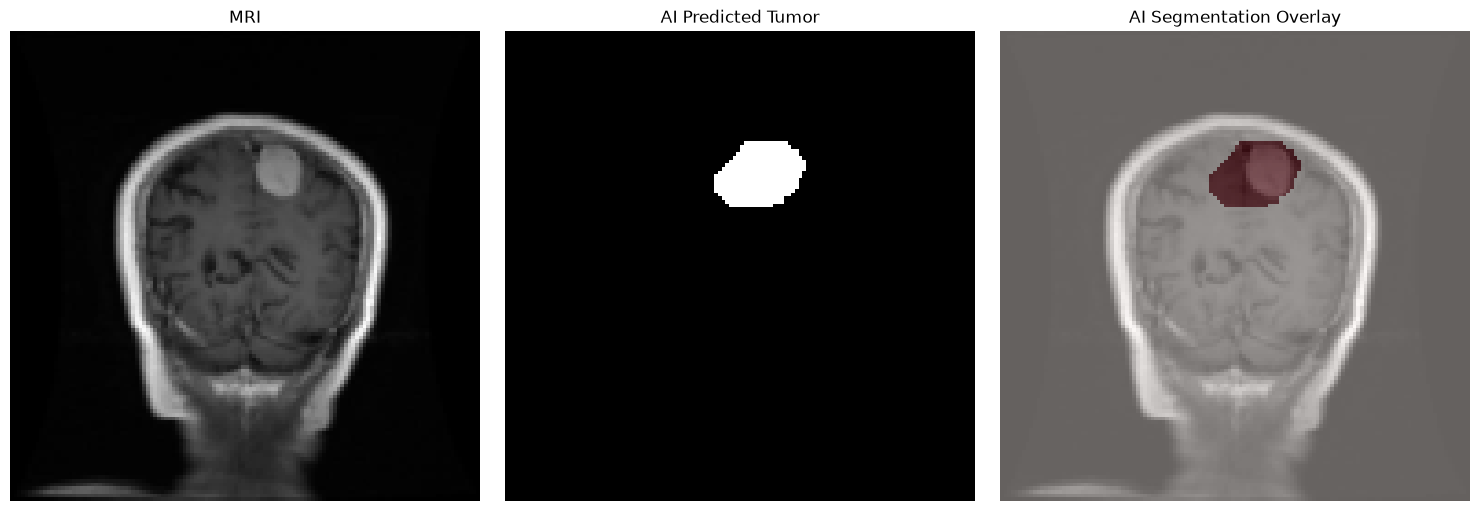

In [50]:
sample = 0

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(X_val[sample].squeeze(), cmap="gray")
plt.title("MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(ai_mask, cmap="gray")
plt.title("AI Predicted Tumor")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(X_val[sample].squeeze(), cmap="gray")
plt.imshow(ai_mask, cmap="Reds", alpha=0.4)
plt.title("AI Segmentation Overlay")
plt.axis("off")

plt.tight_layout()
plt.savefig(
    "results/ai_segmentation_overlay.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

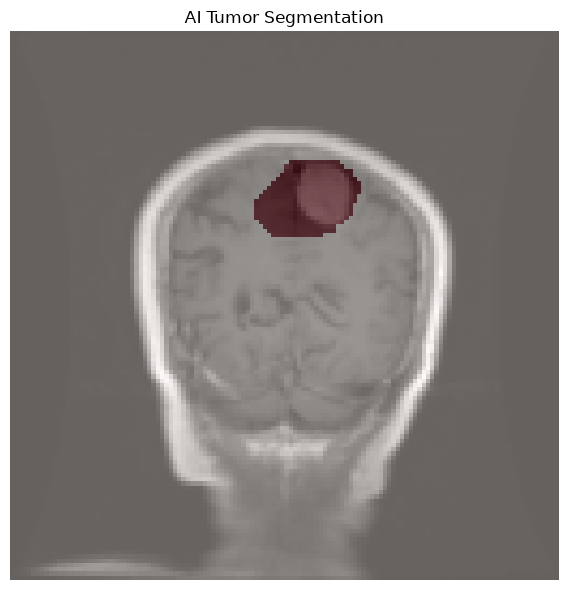

Final AI mask saved.
Final overlay saved.


In [51]:
# Save the final AI segmentation mask
ai_mask = (
    all_val_predictions[0].squeeze() > 0.45
).astype(np.uint8) * 255

Image.fromarray(ai_mask).save(
    "results/ai_predicted_tumor_mask.png"
)

# Save the overlay again
plt.figure(figsize=(6, 6))
plt.imshow(X_val[0].squeeze(), cmap="gray")
plt.imshow(ai_mask, cmap="Reds", alpha=0.4)
plt.title("AI Tumor Segmentation")
plt.axis("off")
plt.tight_layout()

plt.savefig(
    "results/ai_segmentation_overlay.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

print("Final AI mask saved.")
print("Final overlay saved.")

In [52]:
import os

print(os.path.abspath("results/ai_predicted_tumor_mask.png"))
print(os.path.exists("results/ai_predicted_tumor_mask.png"))

C:\Users\areej\Documents\brain-mri-tumor-segmentation\notebooks\results\ai_predicted_tumor_mask.png
True


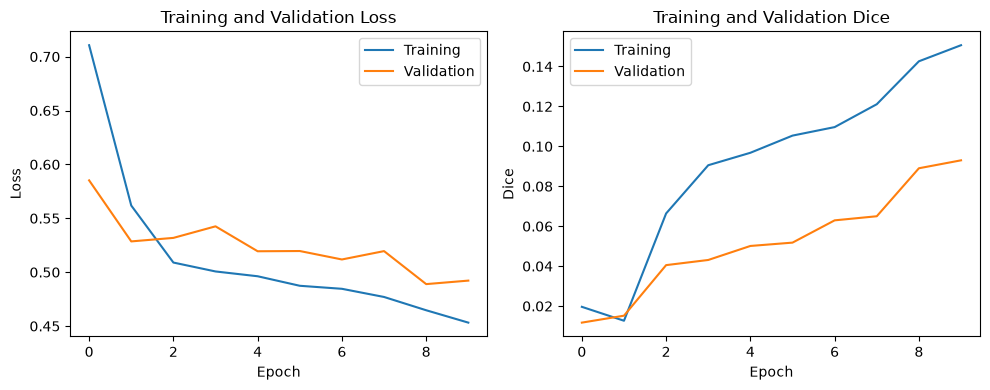

In [53]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history_ai.history["loss"])
plt.plot(history_ai.history["val_loss"])
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training", "Validation"])

plt.subplot(1,2,2)
plt.plot(history_ai.history["dice_coefficient"])
plt.plot(history_ai.history["val_dice_coefficient"])
plt.title("Training and Validation Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend(["Training", "Validation"])

plt.tight_layout()

plt.savefig(
    "results/training_curves.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()